In [39]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
from pathlib import Path

In [40]:
sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from load_data import read_data, create_combined_dataset

path = "../ALLDataGross/healthyCohort"
dataframes = read_data(path)


Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/healthyCohort/20180205-16-CW-TB.16.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171109-22-SR-TB-M1.22.dpt'), PosixPath('../ALLDataGross/healthyCohort/20190606-15-KW-TB.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171123-18-AA-ExD.dpt'), PosixPath('../ALLDataGross/healthyCohort/20180205-01-OL-TB.dpt'), PosixPath('../ALLDataGross/healthyCohort/20190405-05-004.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171109-16-AL-TB-M1.16.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171109-01-EL-TB-8y.01.dpt'), PosixPath('../ALLDataGross/healthyCohort/20180802-05-MF-TB.dpt'), PosixPath('../ALLDataGross/healthyCohort/20190405-02-001.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171109-17-AH-TB-M1.17.dpt'), PosixPath('../ALLDataGross/healthyCohort/Healthy.mat'), PosixPath('../ALLDataGross/healthyCohort/20171109-02-PL-TB-5y.02.dpt'), PosixPath('../ALLDataGross/healthyCohort/20171109-04-OG-TB-M1.04.dpt'), PosixPath('.

### Test on 1 sample spectra

In [41]:
sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from baseline_correct import baseline_roy, baseline_intermediates


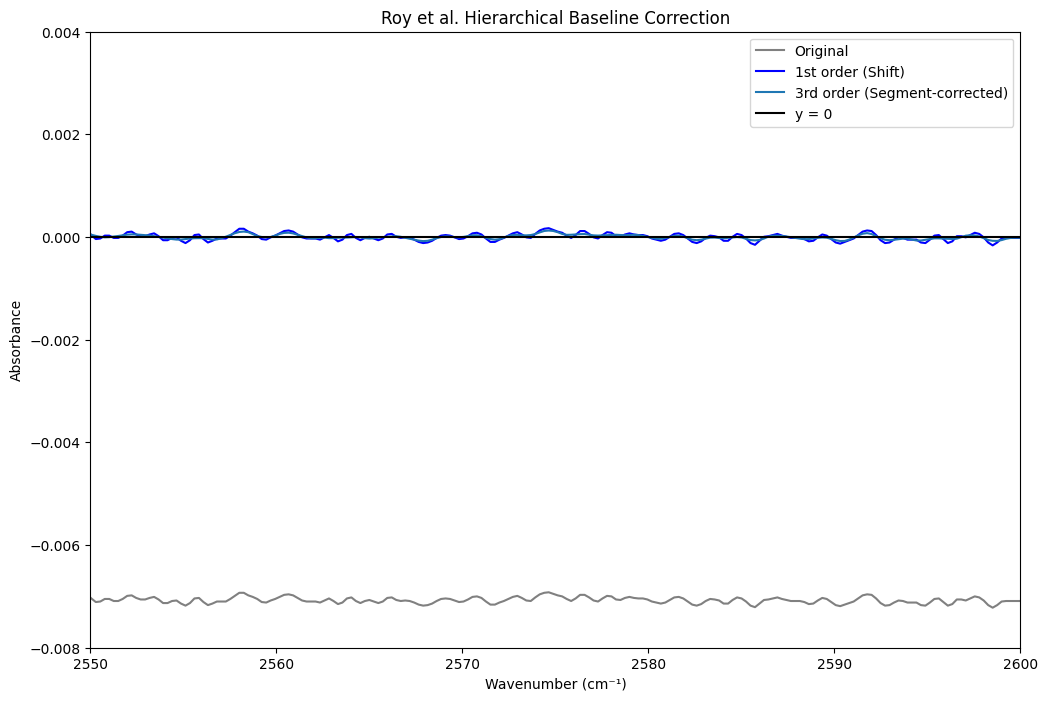

In [42]:
# Example usage
from matplotlib import style

i = 3
normVP = [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]
filename, df = dataframes[i]
norm_factor_i = normVP[i]
x = df['Wavenumber'].values
y = df['Intensity'].values

segment_edges = [990, 1020]
y_stage3 = baseline_roy(x, y, norm_factor_i=norm_factor_i)
y_stage2, y_stage1 = baseline_intermediates(x, y, norm_factor_i = norm_factor_i)
baseline = y - y_stage3

# visualize
plt.figure(figsize=(12,8))
plt.plot(x, y, label='Original', color='grey')
plt.plot(x, y_stage1, label='1st order (Shift)', color = 'blue')
# plt.plot(x, y_stage2, label='2nd order (Tilt removed)', color ='red')
plt.plot(x, y_stage3, label='3rd order (Segment-corrected)')
# plt.plot(x, baseline, label="baseline")
plt.xlim(2550, 2600)
plt.ylim(-0.008, 0.004)
# plt.xlim(2700,)

plt.plot(x, np.zeros(len(y)), label="y = 0",color='black')
# plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend(); plt.title("Roy et al. Hierarchical Baseline Correction")
plt.show()


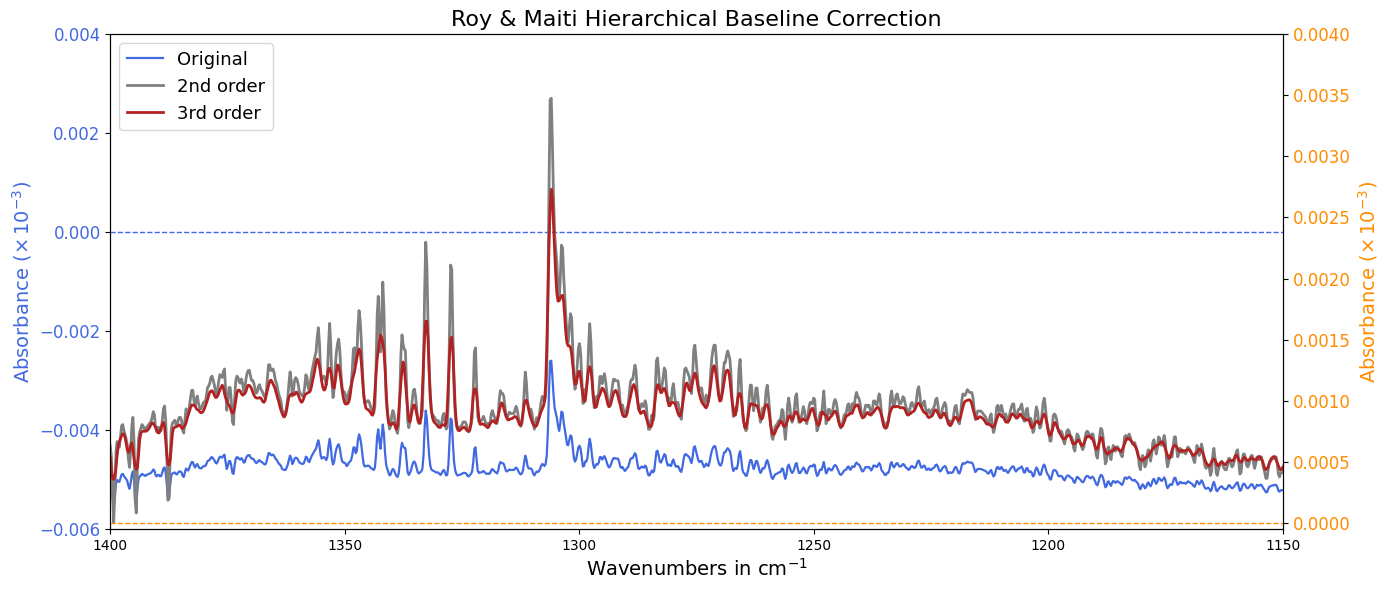

In [43]:
# ======================================
# Replicate Roy & Maiti dual-axis style
# ======================================

i = 2
normVP = [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]
filename, df = dataframes[i]
norm_factor_i = normVP[i]
x = df['Wavenumber'].values
y = df['Intensity'].values

segment_edges = [990, 1020]
y_stage3 = baseline_roy(x, y, norm_factor_i=norm_factor_i)
y_stage2, y_stage1 = baseline_intermediates(x, y, norm_factor_i = norm_factor_i)
baseline = y - y_stage3
fig, ax1 = plt.subplots(figsize=(14,6))

# Primary plot (left axis)
ax1.plot(x, y, label="Original", color='royalblue', linewidth=1.6)
# ax1.plot(x, y_stage2, label="2nd order", color='lightgrey', linewidth=2)
# ax1.plot(x, y_stage3, label="3rd order", color='firebrick', linewidth=2)

# Zero reference lines (left + right)
ax1.axhline(0, linestyle='--', color='royalblue', linewidth=1)
# ax2 line added later

# Axis labels & scale formatting
ax1.set_xlabel("Wavenumbers in cm$^{-1}$", fontsize=14)
ax1.set_ylabel(r"Absorbance ($\times \,10^{-3}$)", fontsize=14, color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue', labelsize=12)
ax1.set_ylim(-0.006, 0.004)         # adjust as needed
ax1.set_xlim(1150, 1400)            
ax1.invert_xaxis()

# -------------------------------------------------------------------
# Second axis (right)
ax2 = ax1.twinx()

# Re-plot corrected data scaled differently if desired
ax2.plot(x, y_stage2, label="2nd order", color='grey', linewidth=2)
ax2.plot(x, y_stage3, label="3rd order", color='firebrick', linewidth=2)
ax2.plot(x, y_stage3*1000, color='firebrick', alpha=0)  # invisible, only sets scale
ax2.set_ylabel(r"Absorbance ($\times \,10^{-3}$)", fontsize=14, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=12)
ax2.set_ylim(-0.00005, 0.004)                 # second y-axis range
ax2.axhline(0, linestyle='--', color='darkorange', linewidth=1)

# -------------------------------------------------------------------
# Collect handles from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=13)


plt.title("Roy & Maiti Hierarchical Baseline Correction", fontsize=16)
plt.tight_layout()
plt.show()


In [44]:
path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG" ,
     "KG", "KG", "KG", "KG", "KG" ,"KG", "KG" ,"KG", "KG", "KG"],
          ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]
combined_df = create_combined_dataset(path,normVP,infoP)




Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

In [45]:
combined_df['infoP'] = combined_df['infoP'].replace({
    'M': 'H',
    'F': 'H'
})
print(f"Total patients: {len(combined_df)}")
print(f"Categories distribution:\n{combined_df['category'].value_counts()}")
print(f"metadata distribution:\n{combined_df['infoP'].value_counts()}")

print("\nFirst few patients:")
print(combined_df[['patient_id', 'category', 'normVP', 'infoP', 'spectrum_length']].head())
# print(combined_df.head())
print(combined_df.describe)
print(combined_df.info())
combined_df.head()

Total patients: 74
Categories distribution:
category
allkgdata      29
blinddata      23
healthydata    22
Name: count, dtype: int64
metadata distribution:
infoP
H     30
KG    19
PC    17
BC     5
KC     3
Name: count, dtype: int64

First few patients:
  patient_id   category  normVP infoP  spectrum_length
0    allkg_1  allkgdata     504     H            14517
1    allkg_2  allkgdata     425    PC            14517
2    allkg_3  allkgdata     451    PC            14517
3    allkg_4  allkgdata     454     H            14517
4    allkg_5  allkgdata     450    PC            14517
<bound method NDFrame.describe of     patient_id  original_filename     category  normVP infoP  \
0      allkg_1    20190405-02-001    allkgdata     504     H   
1      allkg_2    20190405-03-002    allkgdata     425    PC   
2      allkg_3    20190405-04-003    allkgdata     451    PC   
3      allkg_4    20190405-05-004    allkgdata     454     H   
4      allkg_5    20190405-06-005    allkgdata     450    PC  

,patient_id,original_filename,category,normVP,infoP,wavenumber,intensity,spectrum_length
0,allkg_1,20190405-02-001,allkgdata,504,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05628, -0.05859, -0.05958, -0.05698, -0.05...",14517
1,allkg_2,20190405-03-002,allkgdata,425,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05227, -0.05274, -0.05296, -0.05487, -0.05...",14517
2,allkg_3,20190405-04-003,allkgdata,451,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06495, -0.06361, -0.06284, -0.06221, -0.06...",14517
3,allkg_4,20190405-05-004,allkgdata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517
4,allkg_5,20190405-06-005,allkgdata,450,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06155, -0.05976, -0.05649, -0.05513, -0.05...",14517


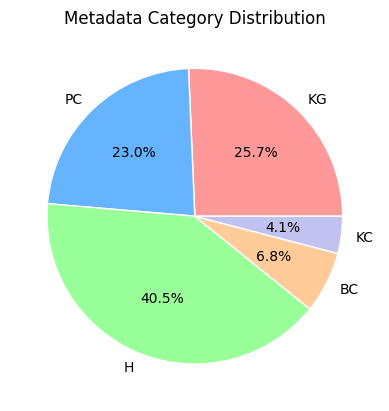

In [46]:
import matplotlib.pyplot as plt

# Data
labels = ['KG', 'PC','H', 'BC', 'KC']
counts = [19, 17, 30, 5, 3]

# Vibrant pastel colors
colors = [
    "#FF9999",  # soft red
    "#66B3FF",  # sky blue
    "#99FF99",  # light green
    "#FFCC99",  # peach
    "#C2C2F0",  # lavender
    "#FFB3E6",  # pastel pink
    "#B3E6FF"   # aqua
]

plt.figure()
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title("Metadata Category Distribution")
plt.show()


In [47]:

# # Normalize by normVP
# combined_df['intensity_normalized'] = None
# for idx, row in combined_df.iterrows():
#     if row['normVP'] is not None and row['normVP'] != 0:
#         combined_df.at[idx, 'intensity_normalized'] = np.divide(row['intensity']*500,row['normVP'])
#     else:
#         combined_df.at[idx, 'intensity_normalized'] = row['intensity']

# print("✅ Normalization completed!")
# print(f"DataFrame now has normalized intensity!")
# combined_df.head()

In [48]:
combined_df['intensity_baseline_corrected'] = None
for idx, row in combined_df.iterrows():
    combined_df.at[idx, "intensity_baseline_corrected"] = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseine corrected!")
print(combined_df.head())

0 done!
1 done!
2 done!
3 done!
4 done!
5 done!
6 done!
7 done!
8 done!
9 done!
10 done!
11 done!
12 done!
13 done!
14 done!
15 done!
16 done!
17 done!
18 done!
19 done!
20 done!
21 done!
22 done!
23 done!
24 done!
25 done!
26 done!
27 done!
28 done!
29 done!
30 done!
31 done!
32 done!
33 done!
34 done!
35 done!
36 done!
37 done!
38 done!
39 done!
40 done!
41 done!
42 done!
43 done!
44 done!
45 done!
46 done!
47 done!
48 done!
49 done!
50 done!
51 done!
52 done!
53 done!
54 done!
55 done!
56 done!
57 done!
58 done!
59 done!
60 done!
61 done!
62 done!
63 done!
64 done!
65 done!
66 done!
67 done!
68 done!
69 done!
70 done!
71 done!
72 done!
73 done!
baseine corrected!
  patient_id original_filename   category  normVP infoP  \
0    allkg_1   20190405-02-001  allkgdata     504     H   
1    allkg_2   20190405-03-002  allkgdata     425    PC   
2    allkg_3   20190405-04-003  allkgdata     451    PC   
3    allkg_4   20190405-05-004  allkgdata     454     H   
4    allkg_5   20190405-06-005

In [49]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    74 non-null     object
 1   original_filename             74 non-null     object
 2   category                      74 non-null     object
 3   normVP                        74 non-null     int64 
 4   infoP                         74 non-null     object
 5   wavenumber                    74 non-null     object
 6   intensity                     74 non-null     object
 7   spectrum_length               74 non-null     int64 
 8   intensity_baseline_corrected  74 non-null     object
dtypes: int64(2), object(7)
memory usage: 5.3+ KB


In [50]:
df = combined_df

<Axes: xlabel='category'>

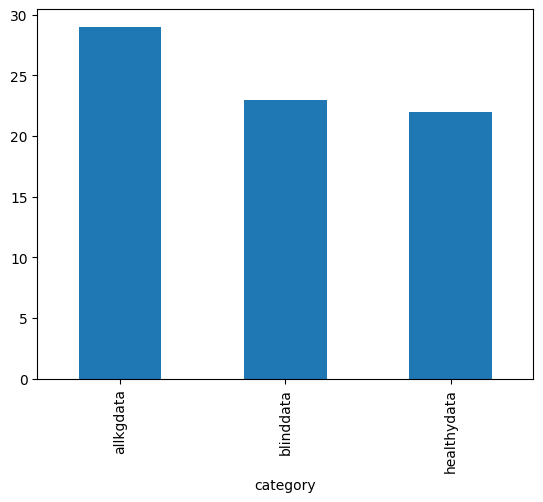

In [51]:
df['category'].value_counts().plot(kind='bar')


<Axes: xlabel='category', ylabel='normVP'>

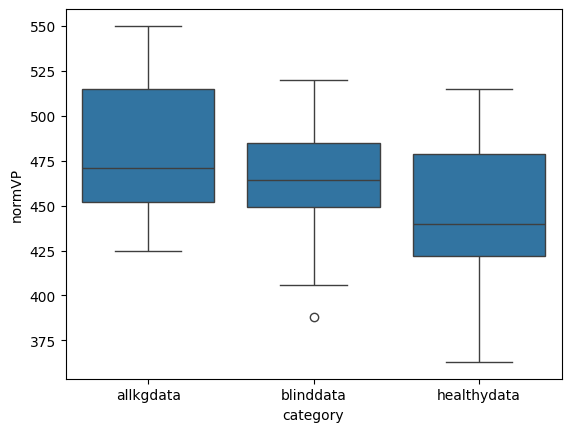

In [52]:
import seaborn as sns
sns.boxplot(x='category', y='normVP', data=df)


In [53]:
print(repr(df['wavenumber'].iloc[0]))


array([ 500.02826,  500.26936,  500.51045, ..., 3999.26172, 3999.50281,
       3999.74391], shape=(14517,))


In [54]:
df = combined_df
df

,patient_id,original_filename,category,normVP,infoP,wavenumber,intensity,spectrum_length,intensity_baseline_corrected
0,allkg_1,20190405-02-001,allkgdata,504,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05628, -0.05859, -0.05958, -0.05698, -0.05...",14517,"[-0.02235369230769231, -0.02957092307692308, -..."
1,allkg_2,20190405-03-002,allkgdata,425,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05227, -0.05274, -0.05296, -0.05487, -0.05...",14517,"[-0.01996602884615385, -0.027064038461538466, ..."
2,allkg_3,20190405-04-003,allkgdata,451,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06495, -0.06361, -0.06284, -0.06221, -0.06...",14517,"[-0.024317278846153843, -0.032105038461538456,..."
3,allkg_4,20190405-05-004,allkgdata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,..."
4,allkg_5,20190405-06-005,allkgdata,450,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06155, -0.05976, -0.05649, -0.05513, -0.05...",14517,"[-0.022687605769230765, -0.02942280769230769, ..."
...,...,...,...,...,...,...,...,...,...
69,healthy_18,20190405-05-004,healthydata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,..."
70,healthy_19,20190606-07-015,healthydata,515,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05534, -0.0554, -0.05566, -0.05547, -0.054...",14517,"[-0.02138491346153846, -0.02851388461538461, -..."
71,healthy_20,20190606-08-016,healthydata,441,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06231, -0.06166, -0.06143, -0.06147, -0.06...",14517,"[-0.023388634615384617, -0.031118846153846153,..."
72,healthy_21,20190606-14-CR-TB,healthydata,404,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05937, -0.05867, -0.05781, -0.05784, -0.05...",14517,"[-0.022163903846153847, -0.029396538461538464,..."


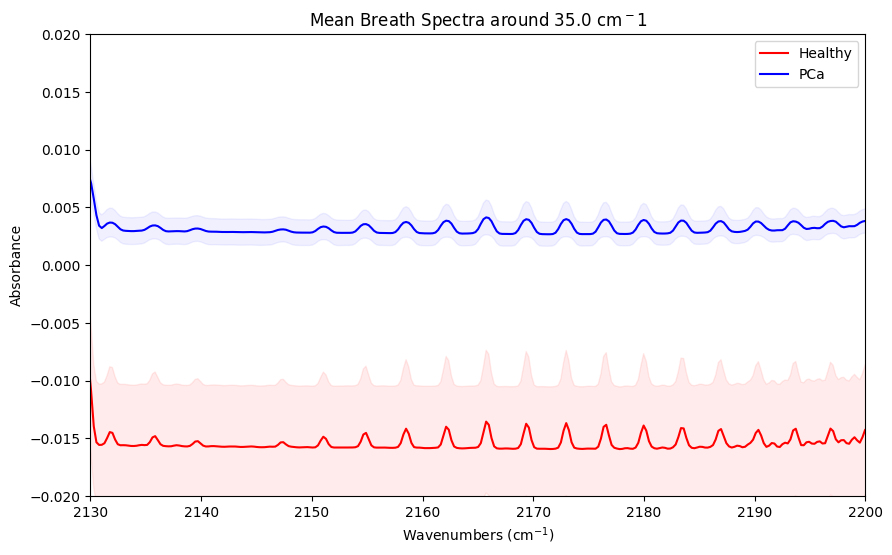

Text(0.5, 0, 'Wavelength (µm)')

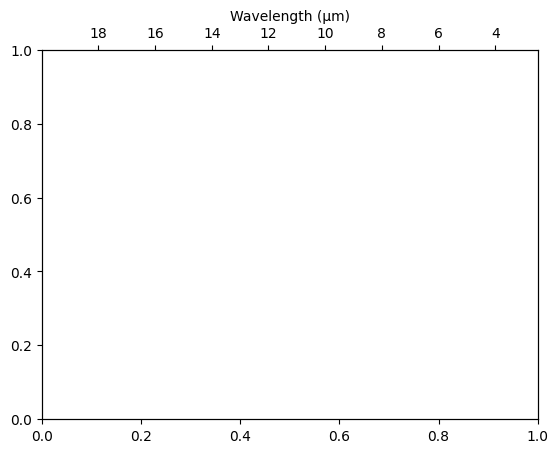

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# filter groups
# healthy = df[df["infoP"] == "H"]
# pca = df[df["infoP"] == "PC"]

x_lo,x_hi = 2130, 2200
y_lo, y_hi = -0.02, 0.02

# stack spectra
original = np.vstack(df["intensity"].to_numpy())
thirdorder = np.vstack(df["intensity_baseline_corrected"].to_numpy())

# compute mean and std
H_mean = np.mean(original, axis=0)
H_std = np.std(original, axis=0)

C_mean = np.mean(thirdorder, axis=0)
C_std = np.std(thirdorder, axis=0)

# shared wavenumber axis
wn = df["wavenumber"].iloc[0]  # assume same for all

plt.figure(figsize=(10,6))

plt.plot(wn, H_mean, color="red", label="Healthy")
plt.fill_between(wn, H_mean-H_std, H_mean+H_std, alpha=0.08, color="red")

plt.plot(wn, C_mean, color="blue", label="PCa")
plt.fill_between(wn, C_mean-C_std, C_mean+C_std, alpha=0.06, color="blue")

plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.xlabel("Wavenumbers (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.legend()
plt.title(f"Mean Breath Spectra around {(x_hi - x_lo) / 2} cm$^{-1}$")
plt.show()

ax1 = plt.gca()
ax2 = ax1.twiny()

# convert wavenumber -> micrometer scale
lambda_um = 1e4 / wn

ax2.set_xlim(lambda_um[0], lambda_um[-1])
ax2.set_xlabel("Wavelength (µm)")





In [78]:
len(wn)

14517

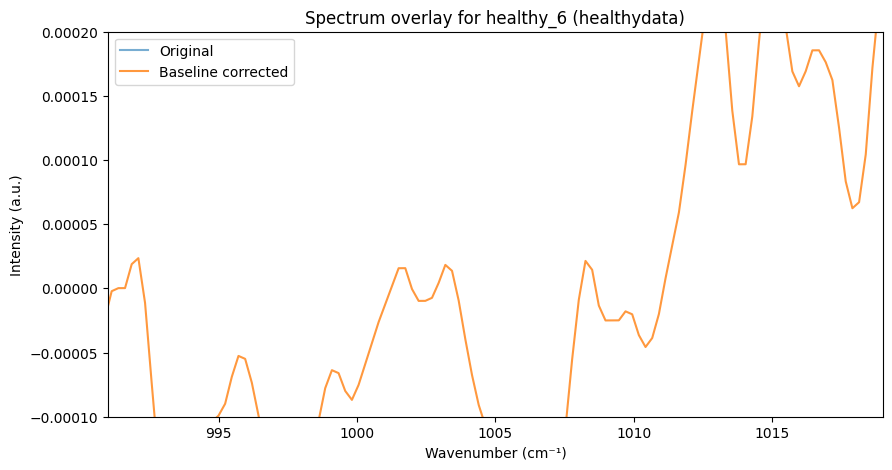

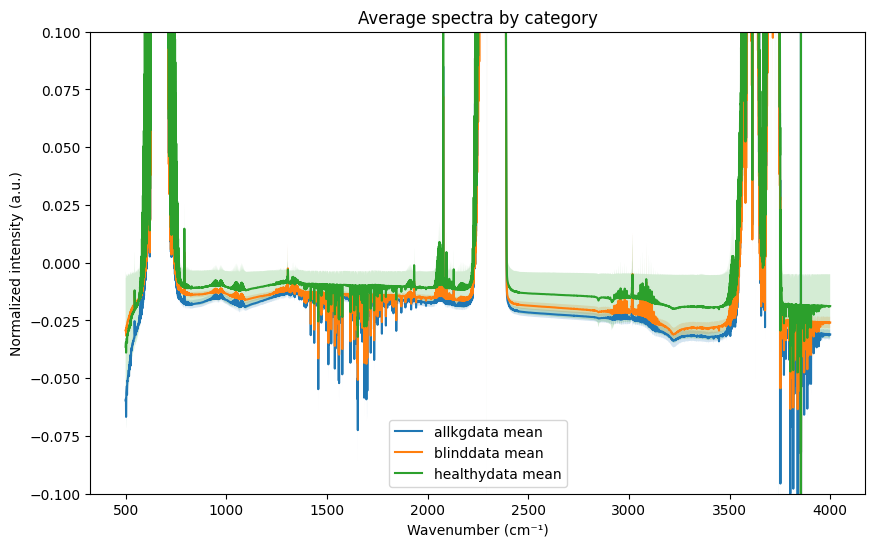

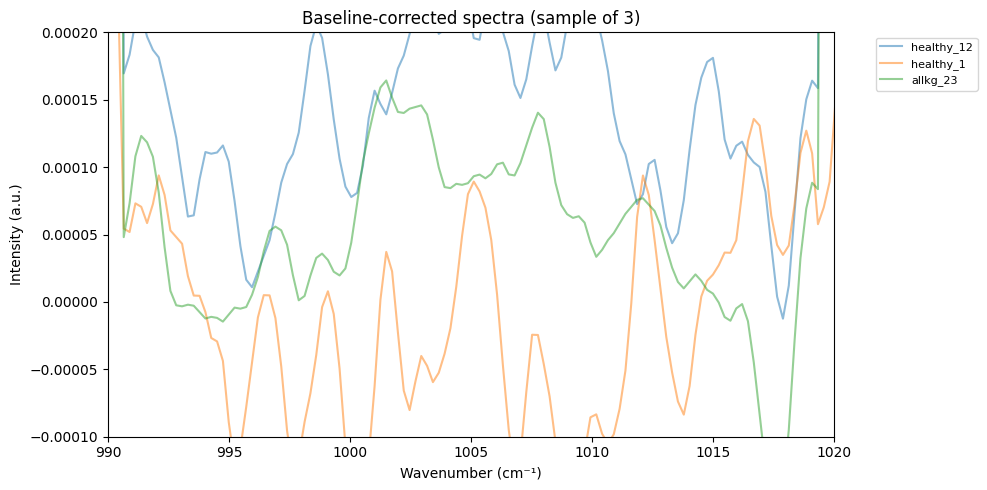

In [56]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np

y_lo, y_high = -0.0001, 0.0002

# Assuming df is your DataFrame
# Convert stringified lists to real lists
for col in ['wavenumber', 'intensity', 'intensity_baseline_corrected']:
    df[col] = df[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x)

# ---- 1️⃣ Single spectrum overlay ----
def plot_single_spectrum(patient_id):
    row = df[df['patient_id'] == patient_id].iloc[0]
    wn = row['wavenumber']
    plt.figure(figsize=(10,5))
    plt.plot(wn, row['intensity'], label='Original', alpha=0.6)
    plt.plot(wn, row['intensity_baseline_corrected'], label='Baseline corrected', alpha=0.8)
    # plt.plot(wn, row['intensity_normalized'], label='Normalized', alpha=0.8)
    plt.title(f"Spectrum overlay for {row['patient_id']} ({row['category']})")
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Intensity (a.u.)")
    plt.xlim(991, 1019)
    plt.ylim(y_lo, y_high)
    plt.legend()
    plt.show()

# Example:
plot_single_spectrum('healthy_6')


# ---- 2️⃣ Category averages ----
def plot_category_means():
    plt.figure(figsize=(10,6))
    for cat, subdf in df.groupby('category'):
        all_norms = np.vstack(subdf['intensity'])
        wn = subdf.iloc[0]['wavenumber']
        mean = all_norms.mean(axis=0)
        std = all_norms.std(axis=0)
        plt.plot(wn, mean, label=f"{cat} mean")
        plt.fill_between(wn, mean-std, mean+std, alpha=0.2)
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Normalized intensity (a.u.)")
    # plt.xlim(990, 1020)
    plt.ylim(-0.1, 0.1)
    plt.title("Average spectra by category")
    plt.legend()
    plt.show()

# Example:
plot_category_means()


# ---- 3️⃣ Multiple baseline-corrected spectra ----
def plot_all_baselines(n=10):
    plt.figure(figsize=(10,5))
    subset = df.sample(min(n, len(df)))
    for _, row in subset.iterrows():
        plt.plot(row['wavenumber'], row['intensity_baseline_corrected'], alpha=0.5, label=row['patient_id'])
    plt.title(f"Baseline-corrected spectra (sample of {n})")
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Intensity (a.u.)")
    plt.xlim(990, 1020)
    plt.ylim(y_lo, y_high)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# Example:
plot_all_baselines(3)


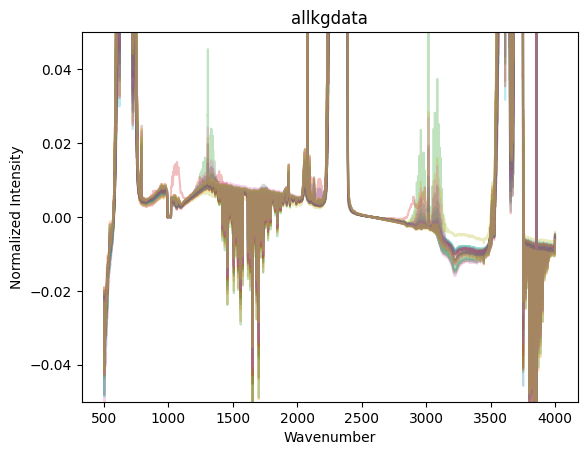

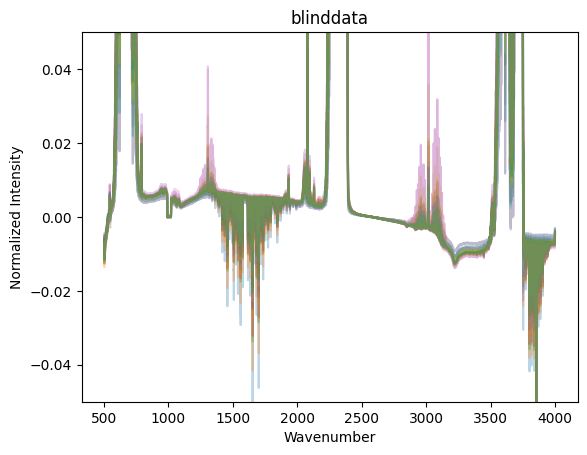

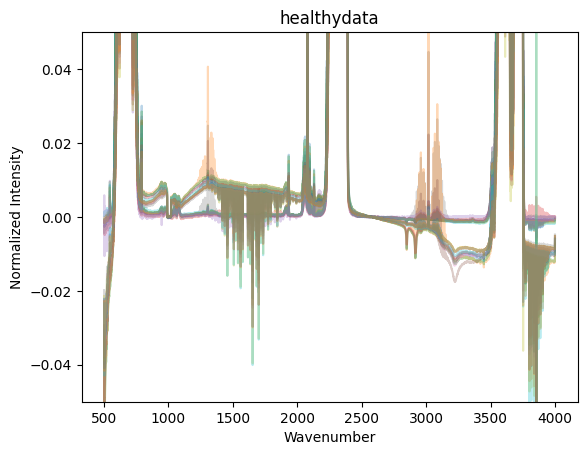

In [57]:
import matplotlib.pyplot as plt

for cat in df['category'].unique():
    subset = df[df['category'] == cat]
    for _, row in subset.iterrows():
        plt.plot(row['wavenumber'], row['intensity_baseline_corrected'], alpha=0.3)
    plt.title(cat)
    plt.xlabel("Wavenumber")
    # plt.xlim(990,1020)
    plt.ylim(-0.05,0.05)
    plt.ylabel("Normalized Intensity")
    plt.show()


patient_id         object
category           object
infoP              object
normVP              int64
spectrum_length     int64
dtype: object
  patient_id   category infoP  normVP  spectrum_length
0    allkg_1  allkgdata     H     504            14517
1    allkg_2  allkgdata    PC     425            14517
2    allkg_3  allkgdata    PC     451            14517
3    allkg_4  allkgdata     H     454            14517
4    allkg_5  allkgdata    PC     450            14517


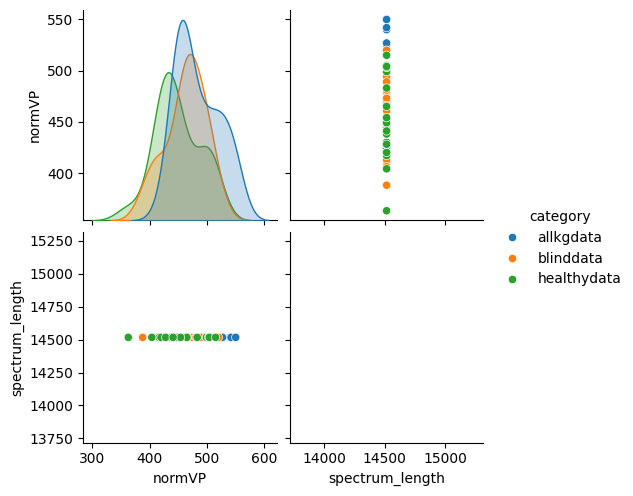

In [58]:
# Make a copy with only simple, numeric or categorical columns
df_simple = df[['patient_id', 'category', 'infoP', 'normVP', 'spectrum_length']].copy()

# Confirm it looks clean
print(df_simple.dtypes)
print(df_simple.head())

# Now the pairplot will work
import seaborn as sns
sns.pairplot(df_simple, vars=['normVP', 'spectrum_length'], hue='category')


snr ratio

In [59]:
# SR_centers = [1005, 530, 1050, 2170, 1190, 1203, 1130, 1170, 2170]  # add others later
# window = 15

# def extract_SR_slices(wavenumber, intensity, center, window):
#     mask = (wavenumber >= center-window) & (wavenumber <= center+window)
#     return intensity[mask]

# df["SR_1005"] = df.apply(lambda row: extract_SR_slices(row["wavenumber"],
#                                                       row["intensity_baseline_corrected"],
#                                                       1005, 5), axis=1)




In [60]:
# for c in SR_centers:
#     df[f"SR_{c}"] = df.apply(lambda row: extract_SR_slices(row["wavenumber"],
#                                                       row["intensity_baseline_corrected"],
#                                                       c, 5), axis=1)



In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    74 non-null     object
 1   original_filename             74 non-null     object
 2   category                      74 non-null     object
 3   normVP                        74 non-null     int64 
 4   infoP                         74 non-null     object
 5   wavenumber                    74 non-null     object
 6   intensity                     74 non-null     object
 7   spectrum_length               74 non-null     int64 
 8   intensity_baseline_corrected  74 non-null     object
dtypes: int64(2), object(7)
memory usage: 5.3+ KB


In [62]:
from numpy import std, mean, max

SR_centers = [1005, 530, 1050, 2170, 1190, 1203, 1130, 1170, 2170]  # add others later

def extract_SR_slices(wavenumber, intensity, center, window):
    mask = (wavenumber >= center-window) & (wavenumber <= center+window)
    return intensity[mask]

def compute_snr(signal):
    noise = signal[:5]  # smallest variation portion or use MAD
    return (max(signal) - mean(noise)) / std(noise)

for c in SR_centers:
    df[f"delta_SNR_{c}"] = (df.apply(lambda row: extract_SR_slices(row["wavenumber"],
                                                      row["intensity"],
                                                      c, 30), axis=1).apply(compute_snr) - df.apply(lambda row: extract_SR_slices(row["wavenumber"],
                                                      row["intensity_baseline_corrected"],
                                                      c, 30), axis=1).apply(compute_snr))

df


,patient_id,original_filename,category,normVP,infoP,wavenumber,intensity,spectrum_length,intensity_baseline_corrected,delta_SNR_1005,delta_SNR_530,delta_SNR_1050,delta_SNR_2170,delta_SNR_1190,delta_SNR_1203,delta_SNR_1130,delta_SNR_1170
0,allkg_1,20190405-02-001,allkgdata,504,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05628, -0.05859, -0.05958, -0.05698, -0.05...",14517,"[-0.02235369230769231, -0.02957092307692308, -...",0.084750,6.956975,24.494952,28.763107,-42.187312,-1710.381205,-310.037859,-38.485183
1,allkg_2,20190405-03-002,allkgdata,425,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05227, -0.05274, -0.05296, -0.05487, -0.05...",14517,"[-0.01996602884615385, -0.027064038461538466, ...",0.020971,14.374844,7.941872,10.648673,-75.824051,-15.606445,-28.181608,-152.138858
2,allkg_3,20190405-04-003,allkgdata,451,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06495, -0.06361, -0.06284, -0.06221, -0.06...",14517,"[-0.024317278846153843, -0.032105038461538456,...",0.050191,21.419473,13.021870,70.206647,-32.476938,-147.355178,-160.298423,-132.334031
3,allkg_4,20190405-05-004,allkgdata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,...",-0.199364,17.389036,17.603507,14.042364,13.409468,-19.917289,-57.637686,-121.842783
4,allkg_5,20190405-06-005,allkgdata,450,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06155, -0.05976, -0.05649, -0.05513, -0.05...",14517,"[-0.022687605769230765, -0.02942280769230769, ...",0.023555,7.947442,25.077050,50.543737,-10.454820,-69.062197,-35.513772,-26.962024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,healthy_18,20190405-05-004,healthydata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,...",-0.199364,17.389036,17.603507,14.042364,13.409468,-19.917289,-57.637686,-121.842783
70,healthy_19,20190606-07-015,healthydata,515,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05534, -0.0554, -0.05566, -0.05547, -0.054...",14517,"[-0.02138491346153846, -0.02851388461538461, -...",-0.034810,134.249480,15.322314,-13.694857,-154.254962,-51.280952,-22.292592,-45.056786
71,healthy_20,20190606-08-016,healthydata,441,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06231, -0.06166, -0.06143, -0.06147, -0.06...",14517,"[-0.023388634615384617, -0.031118846153846153,...",0.056119,101.168957,27.342634,42.330580,2.097618,-24.657752,-42.105796,-12.111287
72,healthy_21,20190606-14-CR-TB,healthydata,404,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05937, -0.05867, -0.05781, -0.05784, -0.05...",14517,"[-0.022163903846153847, -0.029396538461538464,...",0.136691,53.576432,29.555426,31.566299,-13.221312,-20.677441,-6.517217,-37.349641


In [63]:
import numpy as np

def extract_SR_slices(wavenumber, intensity, center, window=30):
    mask = (wavenumber >= center-window) & (wavenumber <= center+window)
    return intensity[mask]

def compute_snr(signal):
    diff = np.diff(signal)  # approximates noise
    noise = np.std(diff)
    return np.max(signal) / noise

    # mean = np.mean(signal)
    # std_dev = np.std(signal)
    # return mean/std_dev

for c in SR_centers:
    raw_snr = df.apply(lambda row: compute_snr(extract_SR_slices(row["wavenumber"], row["intensity"], c)), axis=1)
    corr_snr = df.apply(lambda row: compute_snr(extract_SR_slices(row["wavenumber"], row["intensity_baseline_corrected"], c)), axis=1)
    df[f"delta_SNR_{c}"] = raw_snr - corr_snr


In [64]:
df

,patient_id,original_filename,category,normVP,infoP,wavenumber,intensity,spectrum_length,intensity_baseline_corrected,delta_SNR_1005,delta_SNR_530,delta_SNR_1050,delta_SNR_2170,delta_SNR_1190,delta_SNR_1203,delta_SNR_1130,delta_SNR_1170
0,allkg_1,20190405-02-001,allkgdata,504,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05628, -0.05859, -0.05958, -0.05698, -0.05...",14517,"[-0.02235369230769231, -0.02957092307692308, -...",-112.897247,-10.346339,-56.163577,-133.085688,-810.634997,-788.538907,-674.815329,-734.447614
1,allkg_2,20190405-03-002,allkgdata,425,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05227, -0.05274, -0.05296, -0.05487, -0.05...",14517,"[-0.01996602884615385, -0.027064038461538466, ...",-124.599911,-11.423532,-63.991838,-116.612005,-769.741038,-779.853107,-591.279273,-737.109528
2,allkg_3,20190405-04-003,allkgdata,451,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06495, -0.06361, -0.06284, -0.06221, -0.06...",14517,"[-0.024317278846153843, -0.032105038461538456,...",-86.190410,-14.460295,-40.951955,-85.904399,-527.276851,-299.530170,-790.228639,-838.306485
3,allkg_4,20190405-05-004,allkgdata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,...",-112.749203,-13.999078,-51.450954,-111.894480,-743.843153,-727.611926,-577.505854,-744.032160
4,allkg_5,20190405-06-005,allkgdata,450,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06155, -0.05976, -0.05649, -0.05513, -0.05...",14517,"[-0.022687605769230765, -0.02942280769230769, ...",-115.227790,-10.957362,-55.559968,-127.291940,-831.598833,-869.521686,-679.462351,-735.783497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,healthy_18,20190405-05-004,healthydata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,...",-112.749203,-13.999078,-51.450954,-111.894480,-743.843153,-727.611926,-577.505854,-744.032160
70,healthy_19,20190606-07-015,healthydata,515,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05534, -0.0554, -0.05566, -0.05547, -0.054...",14517,"[-0.02138491346153846, -0.02851388461538461, -...",-113.437072,-21.563293,-59.820359,-149.880829,-814.818885,-725.694651,-638.150216,-792.506128
71,healthy_20,20190606-08-016,healthydata,441,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06231, -0.06166, -0.06143, -0.06147, -0.06...",14517,"[-0.023388634615384617, -0.031118846153846153,...",-80.548418,-20.223575,-38.202192,-85.012978,-992.976943,-979.289188,-778.758093,-833.129556
72,healthy_21,20190606-14-CR-TB,healthydata,404,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05937, -0.05867, -0.05781, -0.05784, -0.05...",14517,"[-0.022163903846153847, -0.029396538461538464,...",-101.297093,-22.133575,-48.736469,-56.488243,-881.230568,-838.775187,-592.901183,-839.747868


,delta_SNR_1005,delta_SNR_530,delta_SNR_1050,delta_SNR_2170,delta_SNR_1190,delta_SNR_1203,delta_SNR_1130,delta_SNR_1170,delta_SNR_2170
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,-90.068333,-25.556750,-46.215913,-87.599752,-660.373918,-619.594674,-565.195877,-653.630617,-87.599752
std,29.688648,11.362687,18.956169,43.248575,260.761007,270.593431,215.197072,248.448035,43.248575
min,-169.729158,-48.901021,-100.204845,-177.511700,-1084.244189,-1172.647010,-919.470482,-1054.895885,-177.511700
25%,-110.932360,-35.282968,-55.538723,-116.613524,-814.818885,-803.819809,-684.202507,-798.974273,-116.613524
50%,-92.002898,-22.136497,-48.535560,-91.707390,-748.698624,-695.193859,-626.611930,-734.447614,-91.707390
75%,-81.887658,-18.067888,-41.741788,-61.238203,-580.288156,-516.914613,-555.863575,-617.952080,-61.238203
max,16.300999,4.042283,5.041310,22.593695,79.935347,78.108678,49.647165,69.868465,22.593695


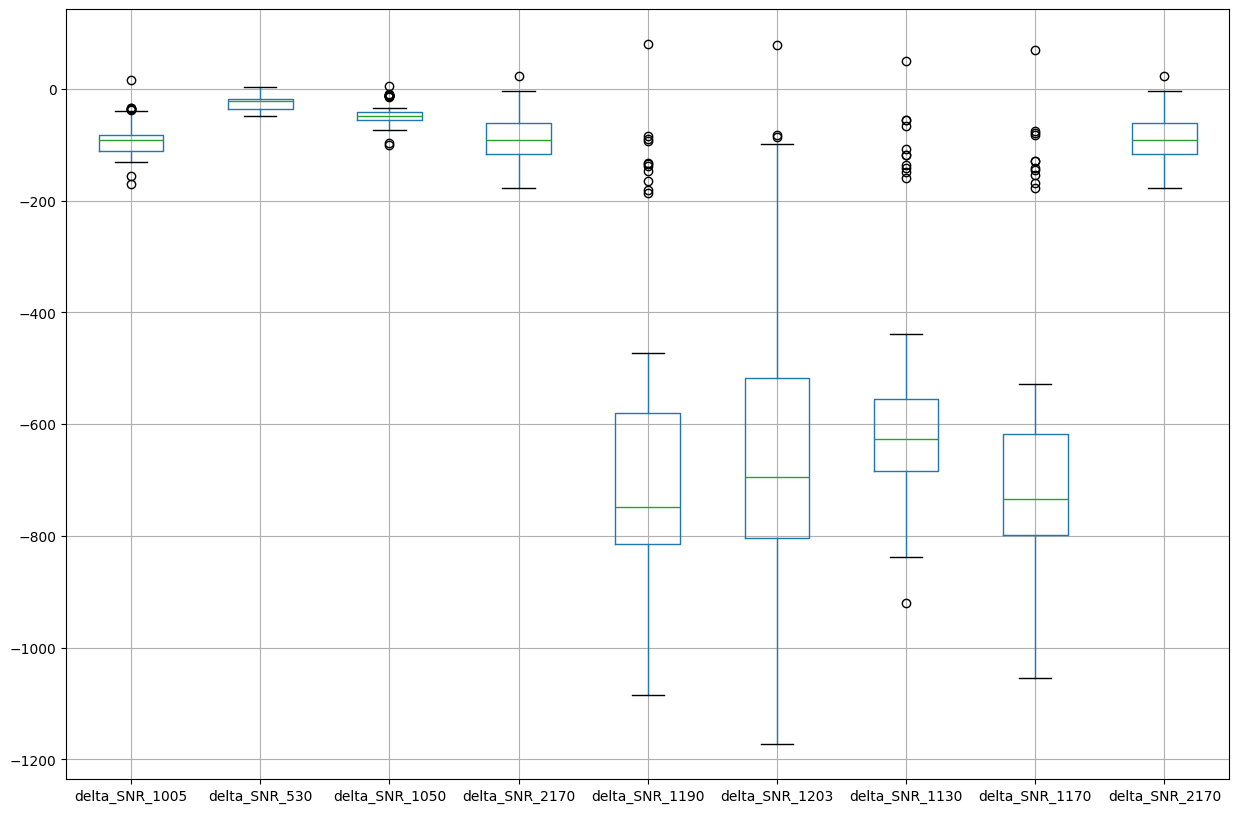

In [65]:
df[[f"delta_SNR_{c}" for c in SR_centers]].boxplot(figsize=(15,10))

df[[f"delta_SNR_{c}" for c in SR_centers]].describe()


In [68]:

import matplotlib.pyplot as plt
import numpy as np

# SR biomarker centers (cm-1)
SR_CENTERS = [1005, 530, 1050, 2170, 1190, 1203, 1130, 1170]
WINDOW = 30   # +/- window size

def plot_SR_zoom(df, sr_centers=SR_CENTERS, window=WINDOW, save=False):
    """
    Create zoomed-in comparison plots around each SR between raw & corrected spectrum.
    """

    for center in sr_centers:
        # Select the first sample to plot or specify row index manually
        # You can loop over patients later if desired
        wav = df.loc[0, "wavenumber"]
        raw = df.loc[0, "intensity"]
        corr = df.loc[0, "intensity_baseline_corrected"]

        mask = (wav >= center-window) & (wav <= center+window)

        plt.figure(figsize=(8,4))
        plt.plot(wav[mask], raw[mask], label="Raw Spectrum", alpha=0.7, linewidth=1.5)
        plt.plot(wav[mask], corr[mask], label="Baseline-Corrected", linewidth=1.5)

        plt.title(f"Zoomed Spectrum around SR @ {center} cm⁻¹")
        plt.xlabel("Wavenumber (cm⁻¹)")
        plt.ylim(-0.001, 0.001)
        plt.ylabel("Absorbance")
        # plt.gca().invert_xaxis()    # common practice in FTIR plots
        plt.legend()
        plt.grid(alpha=0.3)

        if save:
            plt.savefig(f"SR_zoom_{center}.png", dpi=400, bbox_inches="tight")

        plt.show()


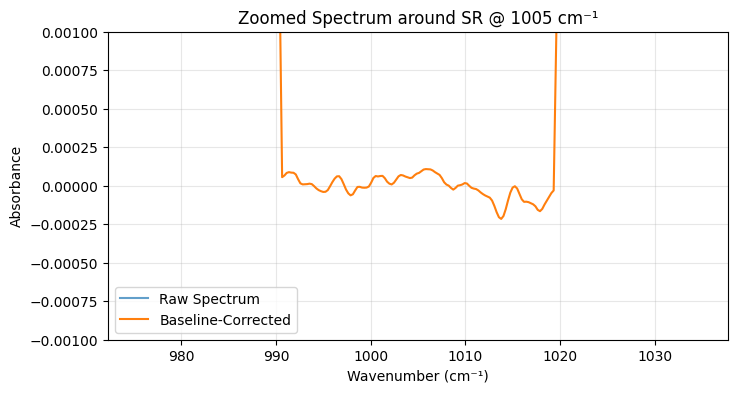

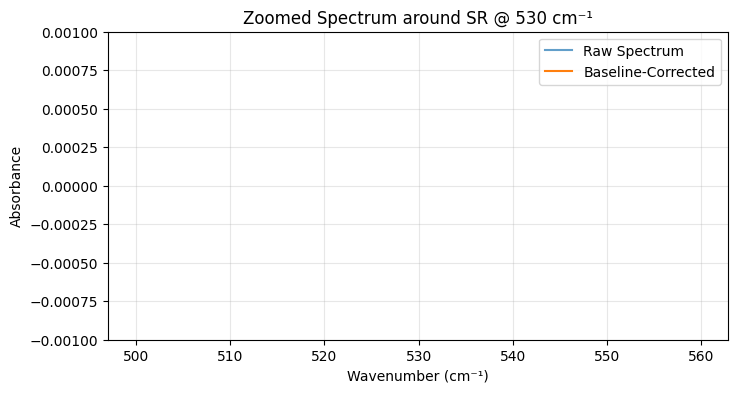

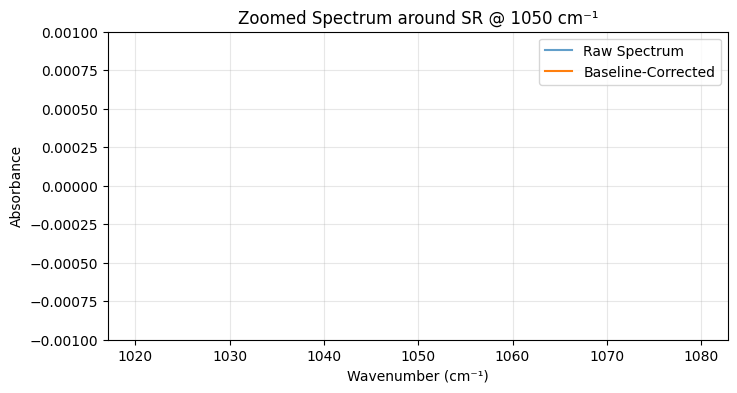

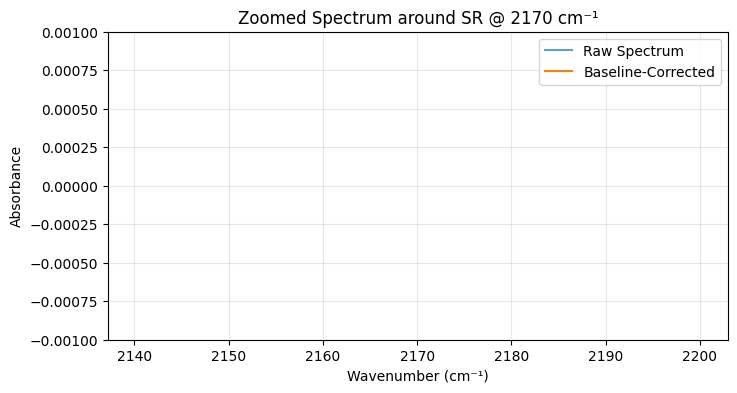

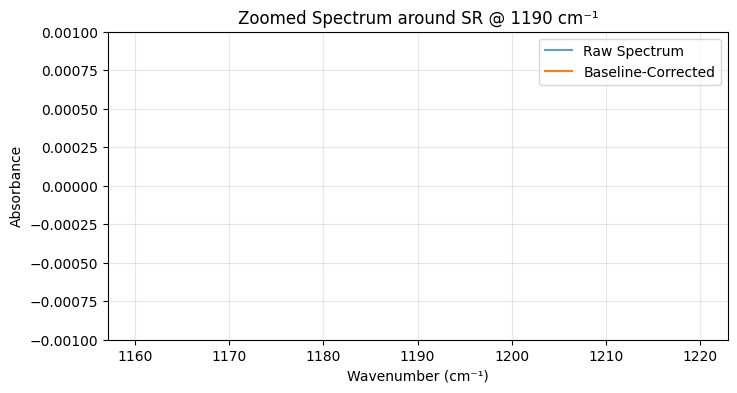

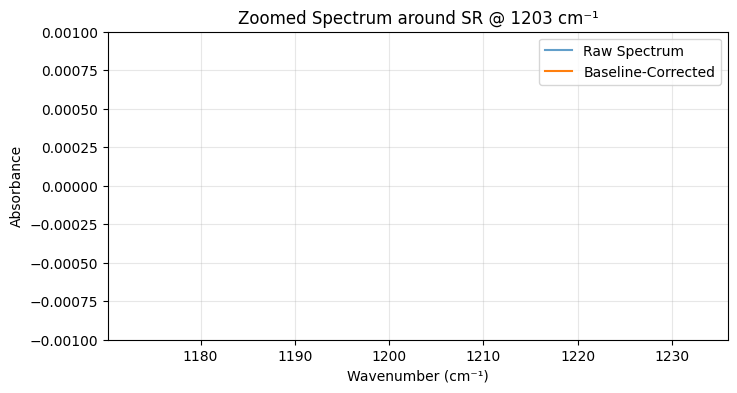

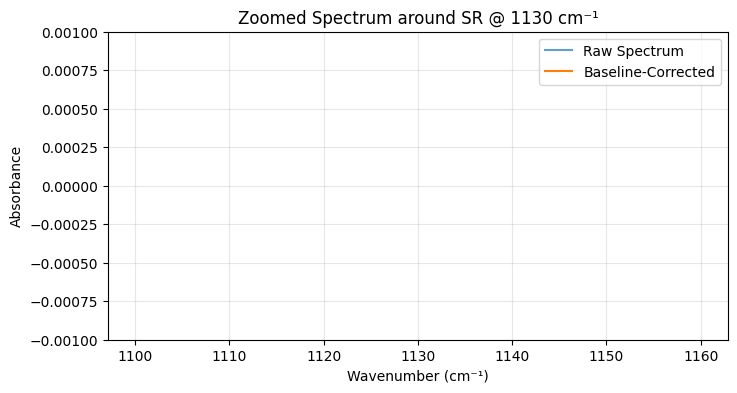

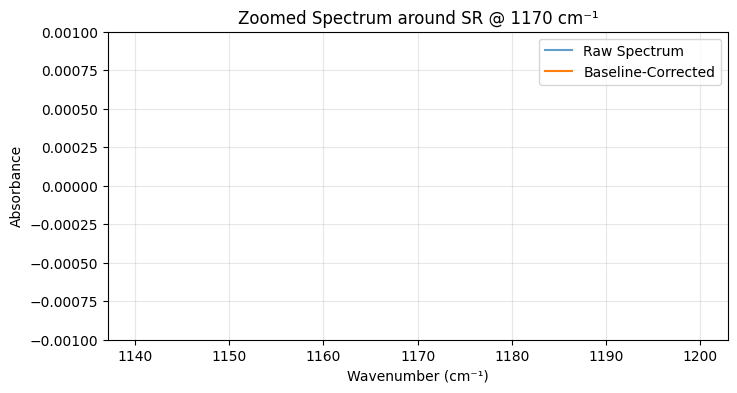

In [69]:
plot_SR_zoom(df)
